## This notebook make a plot showing SCF. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal.windows import nuttall
from matplotlib.colors import LogNorm
import pkfuncs as pfunc
import scipy
from scipy.signal import windows
import plot_scripts as plts
import os
plt.style.use("mplstyle")

/tmp/ipykernel_4088141/3692121350.py:175: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


Saved: plots/Hann_GP_comparison_PERIODIC.pdf


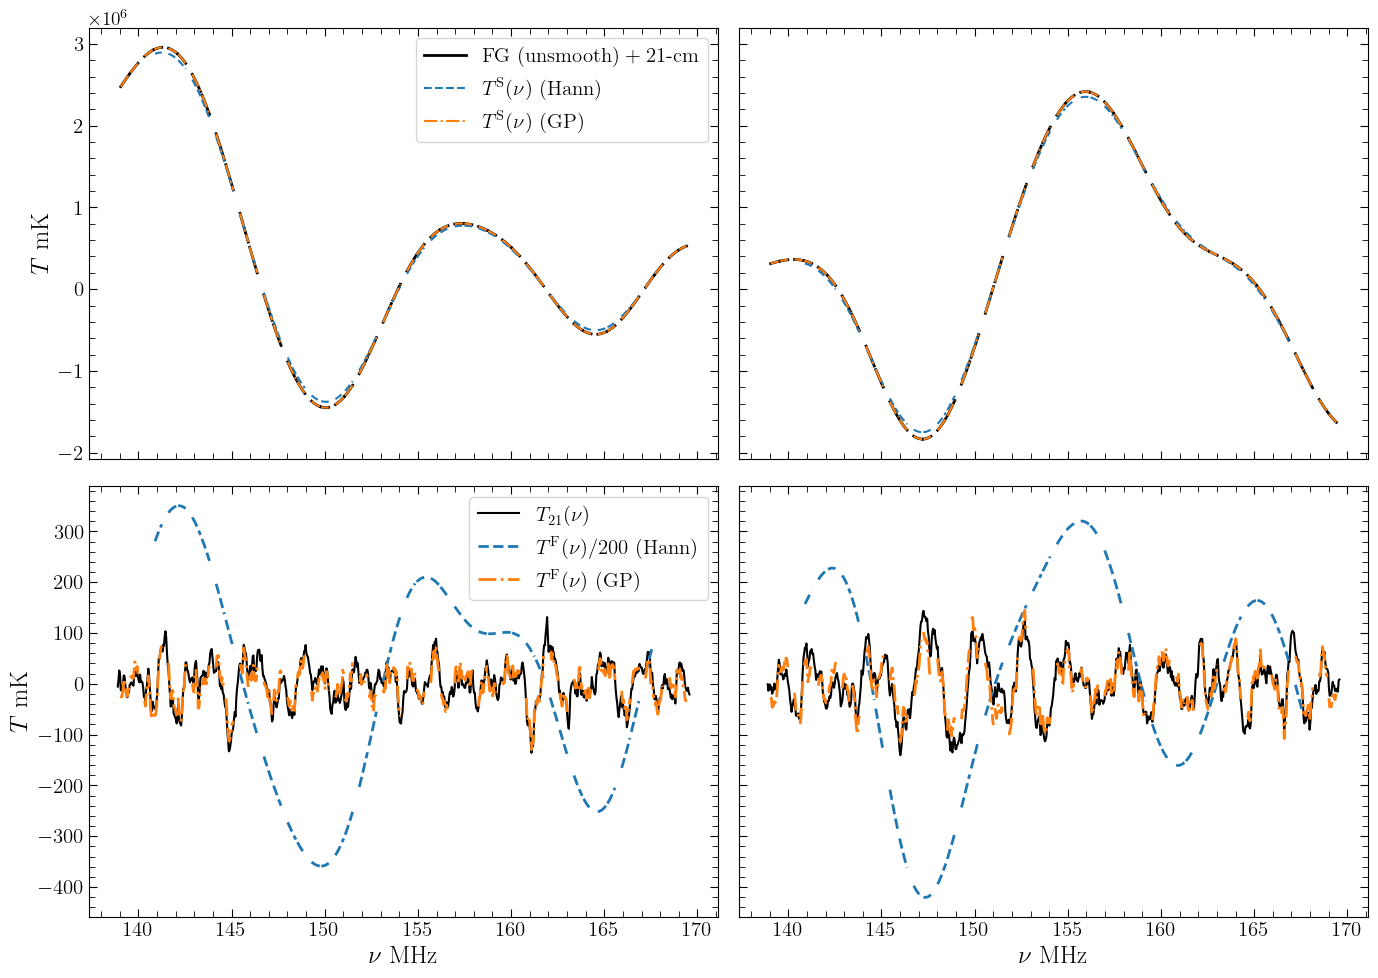

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import os
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

# --- Input Model Parameters ---
n = 2.0
N = 768
dnuc = 40e-3             # MHz
r = 9209.714526830916    # Mpc
rp = 16.98990953034521   # Mpc/MHz
dL = dnuc * rp
L  = N * dL
Nrea = 100

# Try loading nua, else create dummy frequency array
try:
    nua = np.load('nua.npy') / 1e6
    dnu = nua
except FileNotFoundError:
    print("Warning: 'nua.npy' not found. Using linear range.")
    dnu = np.arange(N) * dnuc + 138.0 

# --- Configuration ---
path = "results"
flag_mode = "PERIODIC"  # Updated to RANDOM
NN_hann = 50 
show_inset = False 

# INDICES for the two realizations
idx1 = 45
idx2 = 90 

# --- Helper to load data ---
def get_data(inp_sig, scf_method, idx):
    fname = f"{path}/fields_inp_signal-{inp_sig}_flag-{flag_mode}_SCF-{scf_method}.npz"
    if not os.path.exists(fname):
        print(f"File not found: {fname}")
        return None, None, None
    data = np.load(fname)
    orig = data.get("fields_orig", None)
    val_orig = orig[idx] if (orig is not None and len(orig) > idx) else None
    return data["fields_tota"][idx], data["fields_flag"][idx], val_orig

def get_data21(inp_sig, scf_method, idx):
    # Loads NOFLAG data for the "Truth"
    fname = f"{path}/fields_inp_signal-{inp_sig}_flag-NOFLAG_SCF-{scf_method}.npz"
    if not os.path.exists(fname):
        print(f"File not found: {fname}")
        return None, None, None
    data = np.load(fname)
    orig = data.get("fields_orig", None)
    val_orig = orig[idx] if (orig is not None and len(orig) > idx) else None
    return data["fields_tota"][idx], data["fields_flag"][idx], val_orig
    
# --- Plotting Logic for Single Column ---
def plot_realization(ax_top, ax_bot, idx, show_ylabel=True, show_legend=False):
    # Load Data
    tota_fg_hann, res_hann, _ = get_data("FG+MM+21cm", "Hann", idx=idx) 
    tota_fg_gp,   res_gp, _   = get_data("FG+MM+21cm", "GP",   idx=idx) 
    
    # Load True 21cm (Filtered Residuals from NOFLAG run)
    _, true_21cm, _ = get_data21("21cm", "GP", idx=idx) 

    if res_hann is None or res_gp is None or true_21cm is None:
        print(f"Error: Missing files for idx {idx}.")
        return

    # Data Prep
    x_full = dnu
    flag_mask = (res_gp != 0.0)
    
    tota_fg_flagged = tota_fg_gp.copy()
    tota_fg_flagged[~flag_mask] = np.nan 
    
    # Fits
    fit_gp = tota_fg_gp - res_gp
    fit_gp[~flag_mask] = np.nan
    
    x_hann = x_full[NN_hann : -NN_hann]
    tota_hann_cut = tota_fg_hann[NN_hann : -NN_hann]
    fit_hann = tota_hann_cut - res_hann
    mask_hann = flag_mask[NN_hann : -NN_hann]
    fit_hann[~mask_hann] = np.nan
    
    # Residuals
    res_gp_masked = res_gp.copy()
    res_gp_masked[~flag_mask] = np.nan
    
    res_hann_masked = res_hann.copy()
    res_hann_masked[res_hann_masked == 0] = np.nan
    
    # --- GLOBAL FONT SIZES ---
    FS_LABEL = 18 
    FS_TICK  = 15 
    FS_LEG   = 15 

    ax_top.tick_params(axis='both', which='major', labelsize=FS_TICK)
    ax_bot.tick_params(axis='both', which='major', labelsize=FS_TICK)

    # --- Top Panel: Input + Fits ---
    # Data (Black Solid)
    ax_top.plot(x_full, tota_fg_flagged, color='k', linewidth=2, 
                label=r"$\mathrm{FG\ (unsmooth) + 21\mbox{-}cm}$") 
    
    # Hann Fit (Blue Dashed)
    ax_top.plot(x_hann, fit_hann, color='tab:blue', linestyle='--', linewidth=1.5, 
                label=r'$T^{\mathrm{S}}(\nu) \ \mathrm{(Hann)}$')
    
    # GP Fit (Orange Dash-Dot)
    ax_top.plot(x_full, fit_gp, color='tab:orange', linestyle='-.', linewidth=1.5, 
                label=r'$T^{\mathrm{S}}(\nu) \ \mathrm{(GP)}$')
    
    if show_ylabel:
        ax_top.set_ylabel(r"$T \ \mathrm{mK}$", fontsize=FS_LABEL)
    
    if show_legend:
        ax_top.legend(loc="upper right", frameon=True, fontsize=FS_LEG) 
        
    # --- Optional Inset ---
    if show_inset:
        center_idx = N // 2
        zoom_width = 64
        zoom_slice = slice(center_idx - zoom_width, center_idx + zoom_width)
        x_zoom = x_full[zoom_slice]
        y_zoom = tota_fg_flagged[zoom_slice]
        
        axins = ax_top.inset_axes([0.05, 0.65, 0.35, 0.35]) 
        axins.plot(x_full, tota_fg_flagged, color='k', linewidth=1.5)
        axins.plot(x_hann, fit_hann, color='tab:blue', linestyle='--', linewidth=1.5)
        axins.plot(x_full, fit_gp, color='tab:orange', linestyle='-.', linewidth=1.5)
        axins.set_xlim(x_zoom[0], x_zoom[-1])
        y_min_zoom = np.nanmin(y_zoom)
        y_max_zoom = np.nanmax(y_zoom)
        y_margin = (y_max_zoom - y_min_zoom) * 0.0
        axins.set_ylim(y_min_zoom - y_margin, y_max_zoom + y_margin)
        axins.tick_params(axis='both', which='major', labelsize=12)
        mark_inset(ax_top, axins, loc1=2, loc2=4, fc="none", ec="0.5")

    # --- Bottom Panel: Residuals ---
    
    # True 21cm (Black Solid) - From NOFLAG run (Continuous)
    ax_bot.plot(x_full, true_21cm, color='k', linestyle='-', linewidth=1.5, 
             label=r'$T_{21}(\nu)$')
    
    # Hann (Blue Dashed) - Scaled by 200
    ax_bot.plot(x_hann, res_hann_masked/200, color='tab:blue', linestyle='--', alpha=1, 
             label=r'$T^{\mathrm{F}}(\nu)/200 \ \mathrm{(Hann)}$')
    
    # GP (Orange Dash-Dot)
    ax_bot.plot(x_full, res_gp_masked, color='tab:orange', linestyle='-.', alpha=1, 
             label=r'$T^{\mathrm{F}}(\nu) \ \mathrm{(GP)}$')
    
    if show_ylabel:
        ax_bot.set_ylabel(r"$T \ \mathrm{mK}$", fontsize=FS_LABEL)
    
    ax_bot.set_xlabel(r"$\nu \ \mathrm{MHz}$", fontsize=FS_LABEL)
    
    if show_legend:
        # Adjusted legend to fit nicely
        ax_bot.legend(loc="upper right", ncol=1, frameon=True, fontsize=FS_LEG)


# --- MAIN DRIVER ---

# Create Figure: 2 Rows, 2 Columns
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey='row')

# Plot Realization 1 (Left Column)
plot_realization(axes[0, 0], axes[1, 0], idx1, show_ylabel=True, show_legend=True)

# Plot Realization 2 (Right Column)
plot_realization(axes[0, 1], axes[1, 1], idx2, show_ylabel=False, show_legend=False)

plt.tight_layout()

# Save
save_fname = f"plots/Hann_GP_comparison_{flag_mode}.pdf"
os.makedirs(os.path.dirname(save_fname), exist_ok=True)

plt.savefig(save_fname, dpi=300, bbox_inches='tight')
print(f"Saved: {save_fname}")

plt.show()

In [3]:
%%%%%%%

UsageError: Cell magic `%%%%%%%` not found.


In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt
# import os
# from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

# # --- Input Model Parameters ---
# n = 2.0
# N = 768
# dnuc = 40e-3             # MHz
# r = 9209.714526830916    # Mpc
# rp = 16.98990953034521   # Mpc/MHz
# dL = dnuc * rp
# L  = N * dL
# Nrea = 100

# # Try loading nua, else create dummy frequency array
# try:
#     nua = np.load('nua.npy') / 1e6
#     dnu = nua
# except FileNotFoundError:
#     print("Warning: 'nua.npy' not found. Using linear range.")
#     dnu = np.arange(N) * dnuc + 138.0 

# # --- Configuration ---
# path = "results"
# flag_mode = "PERIODIC"
# NN_hann = 50 
# show_inset = False 

# # INDICES for the two realizations
# idx1 = 45
# idx2 = 90 

# # --- Helper to load data ---
# def get_data(inp_sig, scf_method, idx):
#     fname = f"{path}/fields_inp_signal-{inp_sig}_flag-{flag_mode}_SCF-{scf_method}.npz"
#     if not os.path.exists(fname):
#         print(f"File not found: {fname}")
#         return None, None, None
#     data = np.load(fname)
    
#     # Safe load for fields_orig
#     orig = data.get("fields_orig", None)
#     val_orig = orig[idx] if (orig is not None and len(orig) > idx) else None
        
#     return data["fields_tota"][idx], data["fields_flag"][idx], val_orig

# # --- Plotting Logic ---
# def plot_realization(ax_top, ax_mid, ax_bot, idx, show_ylabel=True, show_legend=False):
#     # 1. Load Main Results (FG + 21cm)
#     tota_fg_hann, res_hann, _ = get_data("FG+MM+21cm", "Hann", idx=idx) 
#     tota_fg_gp,   res_gp, _   = get_data("FG+MM+21cm", "GP",   idx=idx) 
    
#     # 2. Load "True" 21cm Filtered Signals (The Truth)
#     _, true_21cm_res_hann, _ = get_data("21cm", "Hann", idx=idx)
#     _, true_21cm_res_gp, _   = get_data("21cm", "GP",   idx=idx)

#     if res_hann is None or res_gp is None:
#         print(f"Error: Missing files for idx {idx}.")
#         return

#     # Data Prep
#     x_full = dnu
#     flag_mask = (res_gp != 0.0)
    
#     # Mask Total Input
#     tota_fg_flagged = tota_fg_gp.copy()
#     tota_fg_flagged[~flag_mask] = np.nan 
    
#     # Calculate Fits
#     fit_gp = tota_fg_gp - res_gp
#     fit_gp[~flag_mask] = np.nan
    
#     x_hann = x_full[NN_hann : -NN_hann]
#     tota_hann_cut = tota_fg_hann[NN_hann : -NN_hann]
#     fit_hann = tota_hann_cut - res_hann
#     mask_hann = flag_mask[NN_hann : -NN_hann]
#     fit_hann[~mask_hann] = np.nan
    
#     # Mask Residuals (Data)
#     res_gp_masked = res_gp.copy()
#     res_gp_masked[~flag_mask] = np.nan
    
#     res_hann_masked = res_hann.copy()
#     res_hann_masked[res_hann_masked == 0] = np.nan 
    
#     # Mask "True" 21cm Residuals (Apply same flags)
    
#     # GP Truth
#     true_21cm_gp_masked = true_21cm_res_gp.copy()
#     true_21cm_gp_masked[~flag_mask] = np.nan
    
#     # Hann Truth (Handle potential trimming)
#     if len(true_21cm_res_hann) == N:
#         true_21cm_hann_cut = true_21cm_res_hann[NN_hann : -NN_hann]
#     else:
#         true_21cm_hann_cut = true_21cm_res_hann
    
#     true_21cm_hann_masked = true_21cm_hann_cut.copy()
#     true_21cm_hann_masked[~mask_hann] = np.nan

#     # --- GLOBAL FONT SIZES ---
#     FS_LABEL = 18 
#     FS_TICK  = 15 
#     FS_LEG   = 13 

#     for ax in [ax_top, ax_mid, ax_bot]:
#         ax.tick_params(axis='both', which='major', labelsize=FS_TICK)

#     # --- TOP PANEL: Input + Fits ---
#     ax_top.plot(x_full, tota_fg_flagged, color='k', linewidth=2, 
#                 label=r"$\mathrm{FG\ (unsmooth) + 21\mbox{-}cm}$") 
#     ax_top.plot(x_hann, fit_hann, color='tab:blue', linestyle='--', linewidth=1.5, 
#                 label=r'$T^{\mathrm{S}}(\nu) \ \mathrm{(Hann)}$')
#     ax_top.plot(x_full, fit_gp, color='tab:orange', linestyle='-.', linewidth=1.5, 
#                 label=r'$T^{\mathrm{S}}(\nu) \ \mathrm{(GP)}$')
    
#     if show_ylabel:
#         ax_top.set_ylabel(r"$T\ \mathrm{mK}$", fontsize=FS_LABEL)
#     if show_legend:
#         ax_top.legend(loc="upper right", frameon=True, fontsize=FS_LEG) 
        
#     # --- MIDDLE PANEL: Hann Residuals ---
#     # Truth (Solid Blue)
#     ax_mid.plot(x_hann, true_21cm_hann_masked, color='k', linestyle='-', linewidth=2, alpha=0.99,
#              label=r'$T_{21}^{\mathrm{F}}(\nu) \ \mathrm{(Hann)}$')
#     # Data (Dashed Blue, Scaled)
#     ax_mid.plot(x_hann, res_hann_masked/100, color='tab:blue', linestyle='--', alpha=0.7, 
#              label=r'$10^{-2} \times T^{\mathrm{F}}(\nu) \ \mathrm{(Hann)}$')
    
#     if show_ylabel:
#         ax_mid.set_ylabel(r"$T\ \mathrm{mK}$", fontsize=FS_LABEL)
#     if show_legend:
#         ax_mid.legend(loc="upper right", ncol=1, frameon=True, fontsize=FS_LEG)

#     # --- BOTTOM PANEL: GP Residuals ---
#     # Truth (Solid Orange)
#     ax_bot.plot(x_full, true_21cm_gp_masked, color='k', linestyle='-', linewidth=2, alpha=0.99,
#              label=r'$T_{21}^{\mathrm{F}}(\nu) \ \mathrm{(GP)}$')
#     # Data (Dash-Dot Orange)
#     ax_bot.plot(x_full, res_gp_masked, color='tab:orange', linestyle='--', alpha=0.8, 
#              label=r'$T^{\mathrm{F}}(\nu) \ \mathrm{(GP)}$')
    
#     if show_ylabel:
#         ax_bot.set_ylabel(r"$T \ \mathrm{mK}$", fontsize=FS_LABEL)
    
#     ax_bot.set_xlabel(r"$\nu \ \mathrm{MHz}$", fontsize=FS_LABEL)
#     if show_legend:
#         ax_bot.legend(loc="upper right", ncol=1, frameon=True, fontsize=FS_LEG)


# # --- MAIN DRIVER ---
# # 3 Rows, 2 Columns
# fig, axes = plt.subplots(3, 2, figsize=(14, 12), sharex=True, sharey='row')

# # Plot Realization 1 (Left Column)
# plot_realization(axes[0, 0], axes[1, 0], axes[2, 0], idx1, show_ylabel=True, show_legend=True)

# # Plot Realization 2 (Right Column)
# plot_realization(axes[0, 1], axes[1, 1], axes[2, 1], idx2, show_ylabel=False, show_legend=False)

# plt.tight_layout()

# save_fname = f"plots/Hann_GP_comparison_{flag_mode}_3panel.pdf"
# os.makedirs(os.path.dirname(save_fname), exist_ok=True)
# plt.savefig(save_fname, dpi=300, bbox_inches='tight')
# print(f"Saved: {save_fname}")

# plt.show()

In [ ]:
# # import numpy as np
# # import matplotlib.pyplot as plt
# # import os
# # from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

# # # --- Input Model Parameters ---
# # n = 2.0
# # N = 768
# # dnuc = 40e-3             # MHz
# # r = 9209.714526830916    # Mpc
# # rp = 16.98990953034521   # Mpc/MHz
# # dL = dnuc * rp
# # L  = N * dL
# # Nrea = 100

# # # Try loading nua, else create dummy frequency array
# # try:
# #     nua = np.load('nua.npy') / 1e6
# #     dnu = nua
# # except FileNotFoundError:
# #     print("Warning: 'nua.npy' not found. Using linear range.")
# #     dnu = np.arange(N) * dnuc + 138.0 

# # # --- Configuration ---
# # path = "results"
# # flag_mode = "PERIODIC"
# # NN_hann = 50 
# # show_inset = False 

# # # INDICES for the two realizations
# # idx1 = 45
# # idx2 = 90 

# # # --- Helper to load data ---
# # # UPDATED: Added flag_arg to allow overriding the global flag_mode
# # def get_data(inp_sig, scf_method, idx, flag_arg=flag_mode):
# #     fname = f"{path}/fields_inp_signal-{inp_sig}_flag-{flag_arg}_SCF-{scf_method}.npz"
# #     if not os.path.exists(fname):
# #         print(f"File not found: {fname}")
# #         return None, None, None
# #     data = np.load(fname)
    
# #     orig = data.get("fields_orig", None)
# #     val_orig = orig[idx] if (orig is not None and len(orig) > idx) else None
        
# #     return data["fields_tota"][idx], data["fields_flag"][idx], val_orig

# # # --- Plotting Logic ---
# # def plot_realization(ax_top, ax_mid, ax_bot, idx, show_ylabel=True, show_legend=False):
# #     # 1. Load Main Results (FG + 21cm) -> Uses PERIODIC flags
# #     tota_fg_hann, res_hann, _ = get_data("FG+MM+21cm", "Hann", idx=idx, flag_arg=flag_mode) 
# #     tota_fg_gp,   res_gp, _   = get_data("FG+MM+21cm", "GP",   idx=idx, flag_arg=flag_mode) 
    
# #     # 2. Load "True" 21cm Filtered Signals -> Uses NOFLAG (Continuous Truth)
# #     # This allows us to see how well we recover the signal "under the flags"
# #     _, true_21cm_res_hann, _ = get_data("21cm", "Hann", idx=idx, )
# #     _, true_21cm_res_gp, _   = get_data("21cm", "GP",   idx=idx, )

# #     if res_hann is None or res_gp is None:
# #         print(f"Error: Missing files for idx {idx}.")
# #         return

# #     # Data Prep
# #     x_full = dnu
    
# #     # Identify Flags from the main run
# #     flag_mask = (res_gp != 0.0)
    
# #     # Mask Total Input (Keep gaps to show data loss)
# #     tota_fg_flagged = tota_fg_gp.copy()
# #     tota_fg_flagged[~flag_mask] = np.nan 
    
# #     # Calculate Fits
# #     fit_gp = tota_fg_gp - res_gp
# #     fit_gp[~flag_mask] = np.nan
    
# #     x_hann = x_full[NN_hann : -NN_hann]
# #     tota_hann_cut = tota_fg_hann[NN_hann : -NN_hann]
# #     fit_hann = tota_hann_cut - res_hann
# #     mask_hann = flag_mask[NN_hann : -NN_hann]
# #     fit_hann[~mask_hann] = np.nan
    
# #     # Mask Residuals (Data has gaps)
# #     res_gp_masked = res_gp.copy()
# #     res_gp_masked[~flag_mask] = np.nan
    
# #     res_hann_masked = res_hann.copy()
# #     res_hann_masked[res_hann_masked == 0] = np.nan 
    
# #     # PREPARE TRUTH (NO MASKS APPLIED - CONTINUOUS)
    
# #     # GP Truth (Full band, Continuous)
# #     true_21cm_gp_cont = true_21cm_res_gp
    
# #     # Hann Truth (Sliced band, Continuous)
# #     if len(true_21cm_res_hann) == N:
# #         true_21cm_hann_cut = true_21cm_res_hann[NN_hann : -NN_hann]
# #     else:
# #         true_21cm_hann_cut = true_21cm_res_hann
# #     true_21cm_hann_cont = true_21cm_hann_cut

# #     # --- GLOBAL FONT SIZES ---
# #     FS_LABEL = 18 
# #     FS_TICK  = 15 
# #     FS_LEG   = 13 

# #     for ax in [ax_top, ax_mid, ax_bot]:
# #         ax.tick_params(axis='both', which='major', labelsize=FS_TICK)

# #     # --- TOP PANEL: Input + Fits ---
# #     ax_top.plot(x_full, tota_fg_flagged, color='k', linewidth=2, 
# #                 label=r"$\mathrm{FG\ (unsmooth) + 21\mbox{-}cm}$") 
# #     ax_top.plot(x_hann, fit_hann, color='tab:blue', linestyle='--', linewidth=1.5, 
# #                 label=r'$T^{\mathrm{S}}(\nu) \ \mathrm{(Hann)}$')
# #     ax_top.plot(x_full, fit_gp, color='tab:orange', linestyle='-.', linewidth=1.5, 
# #                 label=r'$T^{\mathrm{S}}(\nu) \ \mathrm{(GP)}$')
    
# #     if show_ylabel:
# #         ax_top.set_ylabel(r"$T$ mK", fontsize=FS_LABEL)
# #     if show_legend:
# #         ax_top.legend(loc="upper right", frameon=True, fontsize=FS_LEG) 
        
# #     # --- MIDDLE PANEL: Hann Residuals ---
# #     # Truth (Solid Black, Continuous)
# #     ax_mid.plot(x_hann, true_21cm_hann_cont, color='k', linestyle='-', linewidth=2, alpha=0.9,
# #              label=r'$T_{21}^{\mathrm{F}}(\nu) \ \mathrm{(Hann)}$')
# #     # Data (Dashed Blue, Scaled, Gapped)
# #     ax_mid.plot(x_hann, res_hann_masked/1e2, color='tab:blue', linestyle='--', alpha=0.7, 
# #              label=r'$10^{-2} \times T^{\mathrm{F}}(\nu) \ \mathrm{(Hann)}$')
    
# #     if show_ylabel:
# #         ax_mid.set_ylabel(r"$T$ mK", fontsize=FS_LABEL)
# #     if show_legend:
# #         ax_mid.legend(loc="upper right", ncol=1, frameon=True, fontsize=FS_LEG)

# #     # --- BOTTOM PANEL: GP Residuals ---
# #     # Truth (Solid Black, Continuous)
# #     ax_bot.plot(x_full, true_21cm_gp_cont, color='k', linestyle='-', linewidth=2, alpha=0.9,
# #              label=r'$T_{21}^{\mathrm{F}}(\nu) \ \mathrm{(GP)}$')
# #     # Data (Dotted Orange, Gapped)
# #     ax_bot.plot(x_full, res_gp_masked, color='tab:orange', linestyle='-', alpha=0.8, linewidth=2,
# #              label=r'$T^{\mathrm{F}}(\nu) \ \mathrm{(GP)}$')
    
# #     if show_ylabel:
# #         ax_bot.set_ylabel(r"$T$ mK", fontsize=FS_LABEL)
    
# #     ax_bot.set_xlabel(r"$\nu$ MHz", fontsize=FS_LABEL)
# #     if show_legend:
# #         ax_bot.legend(loc="upper right", ncol=1, frameon=True, fontsize=FS_LEG)


# # # --- MAIN DRIVER ---
# # fig, axes = plt.subplots(3, 2, figsize=(14, 12), sharex=True, sharey='row')

# # plot_realization(axes[0, 0], axes[1, 0], axes[2, 0], idx1, show_ylabel=True, show_legend=True)
# # plot_realization(axes[0, 1], axes[1, 1], axes[2, 1], idx2, show_ylabel=False, show_legend=False)

# # plt.tight_layout()
# import numpy as np
# import matplotlib.pyplot as plt
# import os
# from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

# # --- Input Model Parameters ---
# n = 2.0
# N = 768
# dnuc = 40e-3             # MHz
# r = 9209.714526830916    # Mpc
# rp = 16.98990953034521   # Mpc/MHz
# dL = dnuc * rp
# L  = N * dL
# Nrea = 100

# # Try loading nua, else create dummy frequency array
# try:
#     nua = np.load('nua.npy') / 1e6
#     dnu = nua
# except FileNotFoundError:
#     print("Warning: 'nua.npy' not found. Using linear range.")
#     dnu = np.arange(N) * dnuc + 138.0 

# # --- Configuration ---
# path = "results"
# flag_mode = "PERIODIC"
# NN_hann = 50 
# show_inset = False 

# # INDICES for the two realizations
# idx1 = 45
# idx2 = 90 

# # --- Helper to load data ---
# # UPDATED: Added flag_arg to allow overriding the global flag_mode
# def get_data(inp_sig, scf_method, idx, flag_arg=flag_mode):
#     fname = f"{path}/fields_inp_signal-{inp_sig}_flag-{flag_arg}_SCF-{scf_method}.npz"
#     if not os.path.exists(fname):
#         print(f"File not found: {fname}")
#         return None, None, None
#     data = np.load(fname)
    
#     orig = data.get("fields_orig", None)
#     val_orig = orig[idx] if (orig is not None and len(orig) > idx) else None
        
#     return data["fields_tota"][idx], data["fields_flag"][idx], val_orig

# # --- Plotting Logic ---
# def plot_realization(ax_top, ax_mid, ax_bot, idx, show_ylabel=True, show_legend=False):
#     # 1. Load Main Results (FG + 21cm) -> Uses PERIODIC flags
#     tota_fg_hann, res_hann, _ = get_data("FG+MM+21cm", "Hann", idx=idx, flag_arg=flag_mode) 
#     tota_fg_gp,   res_gp, _   = get_data("FG+MM+21cm", "GP",   idx=idx, flag_arg=flag_mode) 
    
#     # 2. Load "True" 21cm Filtered Signals -> Uses NOFLAG (Continuous Truth)
#     # This allows us to see how well we recover the signal "under the flags"
#     _, true_21cm_res_hann, _ = get_data("21cm", "Hann", idx=idx, )
#     _, true_21cm_res_gp, _   = get_data("21cm", "GP",   idx=idx, )

#     if res_hann is None or res_gp is None:
#         print(f"Error: Missing files for idx {idx}.")
#         return

#     # Data Prep
#     x_full = dnu
    
#     # Identify Flags from the main run
#     flag_mask = (res_gp != 0.0)
    
#     # Mask Total Input (Keep gaps to show data loss)
#     tota_fg_flagged = tota_fg_gp.copy()
#     tota_fg_flagged[~flag_mask] = np.nan 
    
#     # Calculate Fits
#     fit_gp = tota_fg_gp - res_gp
#     fit_gp[~flag_mask] = np.nan
    
#     x_hann = x_full[NN_hann : -NN_hann]
#     tota_hann_cut = tota_fg_hann[NN_hann : -NN_hann]
#     fit_hann = tota_hann_cut - res_hann
#     mask_hann = flag_mask[NN_hann : -NN_hann]
#     fit_hann[~mask_hann] = np.nan
    
#     # Mask Residuals (Data has gaps)
#     res_gp_masked = res_gp.copy()
#     res_gp_masked[~flag_mask] = np.nan
    
#     res_hann_masked = res_hann.copy()
# plt.show()
# # save_fname = f"plots/Hann_GP_comparison_{flag_mode}_TruthNoFlag.pdf"
# # os.makedirs(os.path.dirname(save_fname), exist_ok=True)
# # plt.savefig(save_fname, dpi=300, bbox_inches='tight')
# # print(f"Saved: {save_fname}")

# # plt.show()